## Analyzing Completed Simulations
Dan Chen, Summer 2026

In [1]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import scipy
from scipy.stats import binned_statistic_2d

from astropy import units as u
from astropy import constants as const
from pathlib import Path
from time import time
from collections import defaultdict
import seaborn as sns
import pickle as pkl
import math

import mmr_id
import rebound_sims as reb_sims

import warnings
warnings.filterwarnings('ignore')

def plot_prettier(dpi=200, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

/Users/danchen/Desktop/EP Research 2026/code/mmr_id.py:106: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.ylabel(f"Two-body resonant angle of {b_name} & {c_name} $\phi$ (degrees)")
/Users/danchen/Desktop/EP Research 2026/code/mmr_id.py:131: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.ylabel(f"Three-body resonant angle of {b_name}, {c_name}, & {d_name} $\phi$ (degrees)")


#### Investigate a specific simulation run & plot it

Dataset 8, Sim 23
num_pl: 3, num_em: 25, num_ptsml: 200
Sigma_1au: 789 g/cm^2, h_1au: 0.017


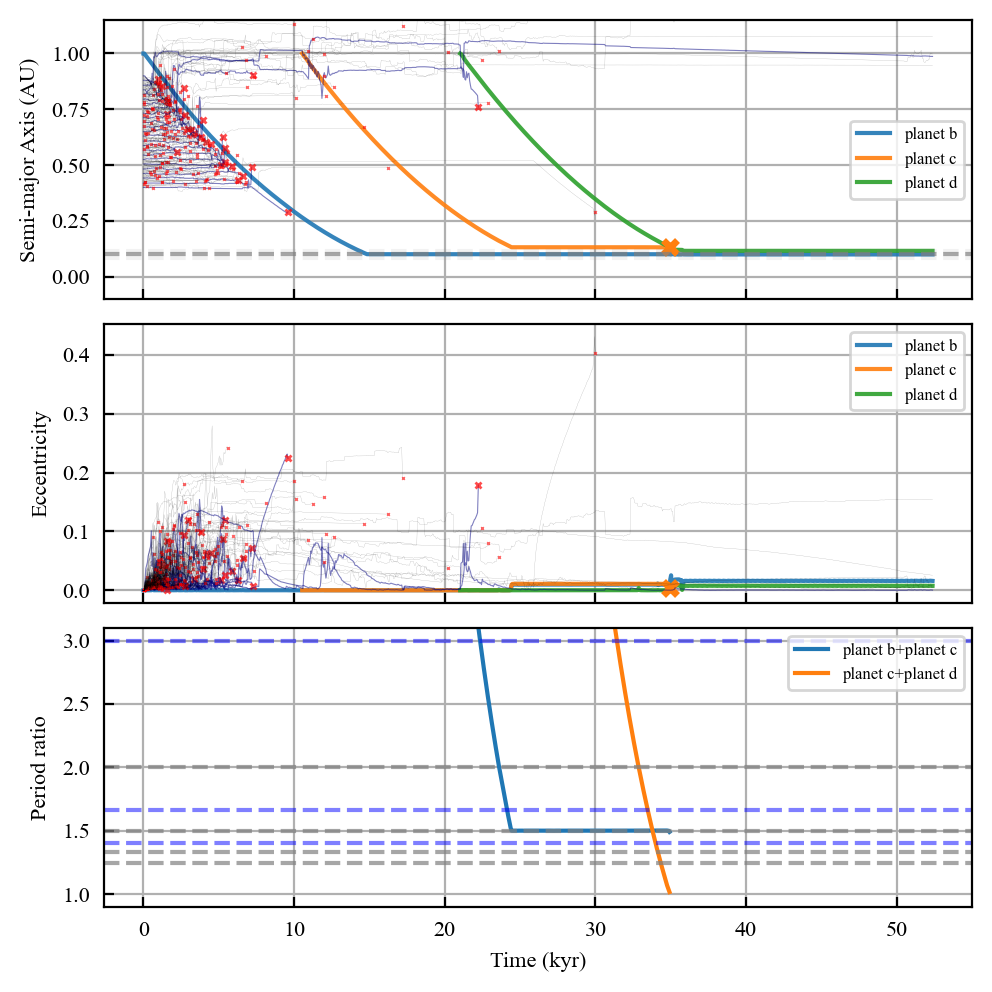

In [6]:
dataset_id = 8
sim_id = 23
%matplotlib inline
base_dir = Path.cwd()
file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
saved_sim = reb_sims.load_simulation_run(file_path)
sim_data, metadata = saved_sim
m_star = metadata['m_star'] 
rock_names = metadata['rock_names']
rocks = {p: sim_data[p] for p in rock_names}
num_pl, num_em, num_ptsml = metadata['num_pl'], metadata['num_em'], metadata['num_ptsml']

# === PLOTTING ===

def plot_end_marker(ax, t, y, **kwargs):
    y = np.asarray(y)

    # Find valid entries
    valid = np.isfinite(y)

    # Only plot marker if the object disappears before the end
    if np.any(valid) and not valid[-1]:
        last_idx = np.where(valid)[0][-1]

        ax.plot(
            t[last_idx],
            y[last_idx],
            marker='x',
            linestyle='None',
            **kwargs
        )

def plot_system(saved_sim, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    # could also try plotting log
    sim_data, metadata = saved_sim
    rock_names = metadata['rock_names']
    times = sim_data[rock_names[0]]['time']
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    fig.set_figwidth(5)
    fig.set_figheight(5)

    time_factor = 1000
    if t_units == 'yr':
        time_factor = 1
    elif t_units == 'Myr': 
        time_factor = 1e6

    for i in range(num_pl):
        name = rock_names[i]

        if t_units == 'kyr':
            ax1.plot(times/time_factor, sim_data[name]["a"], alpha=0.9, label=name)
            ax2.plot(times/time_factor, sim_data[name]["e"], alpha=0.9, label=name)
    
            if i < num_pl-1:
                ax3.plot(times/time_factor, sim_data[rock_names[i+1]]["P"]/sim_data[name]["P"], label=f"{name}+{rock_names[i+1]}")
    
    # Pomegas should be antialigned
    # ax2.plot(times/time_factor, sim_data['planet b']["pomega"]-sim_data['planet c']["pomega"], alpha=0.9, label=name)
    
    # Another loop to prevent color confusion
    for i in range(num_pl):
        name = rock_names[i]
        if t_units == 'kyr':
            plot_end_marker(ax1, times/time_factor, sim_data[name]["a"], c=f'C{i}', ms=5, mew=2.5)
            plot_end_marker(ax2, times/time_factor, sim_data[name]["e"], c=f'C{i}', ms=5, mew=2.5)

    for i in range(0, num_em, 1):
        name = rock_names[i+num_pl]
        
        if t_units == 'kyr':
            ax1.plot(times/time_factor, sim_data[name]["a"], c='navy', alpha=0.5, lw=0.4)
            ax2.plot(times/time_factor, sim_data[name]["e"], c='navy', alpha=0.5, lw=0.4)
            plot_end_marker(ax1, times/time_factor, sim_data[name]["a"], color='r', ms=2, mew=1, alpha=0.7)
            plot_end_marker(ax2, times/time_factor, sim_data[name]["e"], color='r', ms=2, mew=1, alpha=0.7)
    
    for i in range(0, num_ptsml, 1):
        name = rock_names[i+num_pl+num_em]
        
        if t_units == 'kyr':
            ax1.plot(times/time_factor, sim_data[name]["a"], c='k', alpha=0.3, lw=0.1)
            ax2.plot(times/time_factor, sim_data[name]["e"], c='k', alpha=0.3, lw=0.1)
            plot_end_marker(ax1, times/time_factor, sim_data[name]["a"], color='r', ms=1, mew=0.5, alpha=0.6)
            plot_end_marker(ax2, times/time_factor, sim_data[name]["e"], color='r', ms=1, mew=0.5, alpha=0.6)
    
    ax1.set_ylabel("Semi-major Axis (AU)")
    ax2.set_ylabel("Eccentricity")
    ax3.set_ylabel("Period ratio")
    ax3.set_xlabel("Time (kyr)")
    
    ax1.set_ylim(-0.1,1.15)
    # ax2.set_ylim(-0.01,0.25)
    ax3.set_ylim(0.9,3.1)
    
    # Plot ide location & width
    try:
        ax1.axhline(metadata["ide_position"], color='gray', ls='--', alpha=0.7)
        ax1.axhline(metadata["ide_position"] - metadata["ide_width"], color='gray', ls='--', alpha=0.1)
        ax1.axhline(metadata["ide_position"] + metadata["ide_width"], color='gray', ls='--', alpha=0.1)
    except:
        pass

    ax1.legend(fontsize=6); ax2.legend(fontsize=6); ax3.legend(fontsize=6)
    ax1.grid(True); ax2.grid(True); ax3.grid(True)
    
    # Add horizontal lines for resonances
    first_res = [2/1, 3/2, 4/3, 5/4]
    second_res = [3/1, 5/3, 7/5]
    third_res = [4/1, 5/2, 7/4, 8/5]
    
    for r in first_res:
        ax3.axhline(r, color='gray', ls='--', alpha=0.7)
    for r in second_res:
        ax3.axhline(r, color='blue', ls='--', alpha=0.5)
    # for r in third_res:
    #     ax3.axhline(r, color='red', ls='--', alpha=0.5)

    fig.subplots_adjust(hspace=0)

    # plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    # plt.savefig("orbital_evo.svg", bbox_inches="tight")

print(f"Dataset {dataset_id}, Sim {sim_id}")    
print(f"num_pl: {metadata['num_pl']}, num_em: {metadata['num_em']}, num_ptsml: {metadata['num_ptsml']}") 
print(f"Sigma_1au: {metadata['Sigma_1au']:.0f} g/cm^2, h_1au: {metadata['h_1au']:.3f}") 

plot_system(saved_sim, num_pl, num_em, num_ptsml)

In [ ]:
def get_collision_log(metadata):
    """Collects collision log and converts to pd.DataFrame for later use.

    Args:
        metadata (dict): Metadata from simulation; typically comes from saved_sim[1].

    Returns:
        pd.DataFrame: collision_df
    """    
    collision_df = pd.DataFrame(metadata["collision_log"])
    collision_df["time"] = (collision_df["time"] / 1000).round(2)
    collision_df = collision_df.rename(columns={"time": "time (kyr)"})
    collision_df = collision_df.sort_values("time (kyr)")
    collision_df["victim mass"] = (collision_df["victim mass"] / m_earth).round(4)
    collision_df = collision_df.rename(columns={"victim mass": "victim mass (m_earth)"})
    return collision_df

def get_particle_fates(metadata):
    fates_df = (pd.Series(metadata["particle_fate"]).rename("outcome"))
    # # Omit alive particles
    # fates_df = fates_df[fates_df != "alive"]  
    fates_df = fates_df.sort_values()
    fates_df = fates_df.to_frame() 
    return fates_df

collision_df = get_collision_log(metadata)
fates_df = get_particle_fates(metadata)

In [ ]:
def summarize_accretion(collision_df, fates_df, percent=True):
    """Summarizes accretion information.

    Args:
        collision_df (pandas.DataFrame): DataFrame of collision log.
        percent (bool, optional): Whether to show fraction as percentage. 
            Defaults to True.

    Returns:
        pandas.DataFrame: Dataframe containing accretion summary.
    """    
    children = defaultdict(list)

    for _, row in collision_df.iterrows():
        children[row["survivor"]].append(row["victim"])

    def get_all_accreted(body):
        """Returns every particle ultimately accreted by body."""
        accreted = []

        for child in children.get(body, []):
            accreted.append(child)
            accreted.extend(get_all_accreted(child))

        return accreted

    alive_particles = [
        name
        for name, outcome in fates_df["outcome"].items()
        if outcome == "alive"
    ]

    rows = []

    for particle in alive_particles:
        accreted = get_all_accreted(particle)

        n_embryos = sum("embryo" in p for p in accreted)
        n_ptsmls = sum("ptsml" in p for p in accreted)

        rows.append({
            "particle": particle,
            "n_ems": n_embryos,
            "n_ptsmls": n_ptsmls,
            "embryo %": n_embryos / num_em,
            "ptsml %": n_ptsmls / num_ptsml,
        })

    alive_accretion_df = (pd.DataFrame(rows).set_index("particle").sort_index())

    # Keep only particles that actually accreted something
    alive_accretion_df = alive_accretion_df[
        alive_accretion_df["n_ems"] + alive_accretion_df["n_ptsmls"] > 0
    ].sort_values('n_ptsmls', ascending=False) # & sort by ptsmls accreted

    # Remaining unaccreted bodies
    n_alive_ems = num_em - alive_accretion_df["n_ems"].sum()
    n_alive_ptsmls = num_ptsml - alive_accretion_df["n_ptsmls"].sum()

    alive_accretion_df.loc["Survived"] = {
        "n_ems": n_alive_ems,
        "n_ptsmls": n_alive_ptsmls,
        "embryo %": n_alive_ems / num_em,
        "ptsml %": n_alive_ptsmls / num_ptsml,
    }

    if percent:
        # Convert to %
        alive_accretion_df["embryo %"] = (alive_accretion_df["embryo %"]*100).round(2)
        alive_accretion_df["ptsml %"] = (alive_accretion_df["ptsml %"]*100).round(2)

    return alive_accretion_df

summary = summarize_accretion(collision_df, fates_df)
summary

,n_ems,n_ptsmls,embryo %,ptsml %
particle,,,,
planet b,3,48,12.0,24.0
planet c,5,10,20.0,5.0
planet d,3,6,12.0,3.0
embryo 16,0,4,0.0,2.0
embryo 19,0,4,0.0,2.0
embryo 0,0,3,0.0,1.5
embryo 10,0,3,0.0,1.5
embryo 13,0,3,0.0,1.5
embryo 15,0,3,0.0,1.5


In [8]:
# Get additional outcomes for all sims in one dataset
def get_additional_outcomes(dataset_id, num_sims):
    rows = []
    
    for sim_id in range(num_sims):
        base_dir = Path.cwd()
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        saved_sim = reb_sims.load_simulation_run(file_path)
        sim_data, metadata = saved_sim
        
        # Get survival fraction
        collision_df = get_collision_log(metadata)
        fates_df = get_particle_fates(metadata)
        summary = summarize_accretion(collision_df, fates_df)
        surv_rate = summary['ptsml %']['Survived']
        
        # Get ejection fraction
        fates_df = get_particle_fates(metadata)
        ejec_rate = fates_df['outcome'].str.contains('ejected').sum()/len(fates_df)
        
        # Check planet survival
        alive_planets = []
        for name in ['planet b', 'planet c', 'planet d']:
            if not np.isnan(sim_data[name]['a'].iloc[-1]):
                alive_planets.append(name)

        # Check both pairs if all planets are alive
        if len(alive_planets) == 3:
            c = alive_planets[1]; d = alive_planets[2]
            
            # Get P_ratios by direct division
            outer_P_ratio = sim_data[d]['P'].iloc[-1]/sim_data[c]['P'].iloc[-1]
            
            # Check Delta (find p, q such that Delta is closest to 0)
            outer_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[c], sim_data[d])
            outer_Delta = outer_P_ratio/(outer_best[0]/outer_best[1]) - 1
            
            # Check libration of 2BR angle
            outer_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[c], sim_data[d]) != (0,0))
        
        else:
            outer_P_ratio = np.nan
            outer_Delta = np.nan
            outer_librates = np.nan
        
        # Check ratio of remaining pair, call it inner pair
        if len(alive_planets) >=2:
            b = alive_planets[0]; c = alive_planets[1] # this will be the right pair regardless
                
            # Get P_ratios by direct division
            inner_P_ratio = sim_data[c]['P'].iloc[-1]/sim_data[b]['P'].iloc[-1]
                
            # Check Delta (find p, q such that Delta is closest to 0)
            inner_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[b], sim_data[c])
            inner_Delta = inner_P_ratio/(inner_best[0]/inner_best[1]) - 1
            
            # Check libration of 2BR angle
            inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[b], sim_data[c]) != (0,0))

        else:
            inner_P_ratio = np.nan
            inner_Delta = np.nan
            inner_librates = np.nan

        # Create df to store data
        Sigma_1au = metadata['Sigma_1au']
        h_1au = metadata['h_1au']
        
        rows.append({
            "Sigma_1au": Sigma_1au,
            "h_1au": h_1au,
            "surv_rate": surv_rate,
            "ejec_rate": ejec_rate,
            "alive_planets": alive_planets,
            "inner_P_ratio": round(inner_P_ratio, 3),
            "outer_P_ratio": round(outer_P_ratio, 3),
            "inner_P_Delta (%)": round(inner_Delta*100, 1),
            "outer_P_Delta (%)": round(outer_Delta*100, 1),
            "inner_librates": inner_librates,
            "outer_librates": outer_librates,
            "pl_survived": len(alive_planets)
        })
        
    outcomes = pd.DataFrame(rows)
    outcomes.index.name = 'sim_id'
    return outcomes

outcomes = get_additional_outcomes(dataset_id=8, num_sims=28)
outcomes

,Sigma_1au,h_1au,surv_rate,ejec_rate,alive_planets,inner_P_ratio,outer_P_ratio,inner_P_Delta (%),outer_P_Delta (%),inner_librates,outer_librates,pl_survived
sim_id,,,,,,,,,,,,
0,170.000000,0.010000,0.5,0.0,"[planet b, planet c]",1.501,NaN,0.1,NaN,True,NaN,2
1,283.577091,0.010000,1.0,0.0,"[planet b, planet c]",1.335,NaN,0.1,NaN,True,NaN,2
2,473.035098,0.010000,6.0,0.0,"[planet b, planet c, planet d]",1.250,1.066,0.0,-0.1,True,False,3
3,789.070102,0.010000,8.0,0.0,"[planet b, planet c, planet d]",1.199,1.043,-0.1,-2.2,True,False,3
4,1316.248261,0.010000,21.5,0.0,"[planet b, planet d]",1.145,NaN,0.1,NaN,True,NaN,2
5,2195.634431,0.010000,28.0,0.0,"[planet b, planet c]",1.128,NaN,0.3,NaN,True,NaN,2
6,3662.538973,0.010000,36.0,0.0,"[planet b, planet c]",1.113,NaN,0.2,NaN,True,NaN,2
7,6109.483228,0.010000,51.0,0.0,"[planet b, planet d]",1.085,NaN,0.2,NaN,False,NaN,2
8,10191.232255,0.010000,52.5,0.0,"[planet b, planet c, planet d]",1.085,0.997,0.2,-0.3,False,True,3


In [ ]:
def plot_param_scatter(outcomes,
                       value_col,
                       label,
                       cmap='inferno',
                       vmin=None,
                       vmax=None,
                       exp=False,
                       show_text=True,
                       log_cmap=False):

    # Remove bad points
    df = outcomes.copy()

    df = df[
        np.isfinite(df["t_a_P_o"])
        & np.isfinite(df["K_factor"])
        & np.isfinite(df[value_col])
    ]

    # Log axes require positive values
    df = df[
        (df["t_a_P_o"] > 0)
        & (df["K_factor"] > 0)
    ]

    norm = LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None

    fig, ax = plt.subplots(figsize=(6,5))

    sc = ax.scatter(
        df["t_a_P_o"],
        df["K_factor"],
        c=df[value_col],
        cmap=cmap,
        norm=norm,
        s=500,
        edgecolors="k"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"$\tau_a/P_o$")
    ax.set_ylabel(r"$K=\tau_a/\tau_e$")

    # Powers-of-10 ticks
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())

    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())

    ax.minorticks_off()

    # Text labels
    if show_text:

        for _, row in df.iterrows():

            x = row["t_a_P_o"]
            y = row["K_factor"]
            val = row[value_col]

            ax.text(
                x,
                y,
                f"{val:.2e}" if exp else f"{val:.3g}",
                ha="center",
                va="center",
                fontsize=6,
                color="white" if val < 1.25 else 'k'
            )

            # Libration markers
            if value_col == "inner_P_ratio":

                if row.get("inner_librates", False):

                    ax.annotate(
                        "L",
                        xy=(x, y),
                        xytext=(0, -4),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=6,
                        color="C2",
                        fontweight="bold"
                    )

            elif value_col == "outer_P_ratio":

                if row.get("outer_librates", False):

                    ax.annotate(
                        "L",
                        xy=(x, y),
                        xytext=(0, -4),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=6,
                        color="C2",
                        fontweight="bold"
                    )

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(label)

    plt.tight_layout()
    plt.show()
    
plot_param_scatter(outcomes, "inner_P_ratio", "Period Ratio")

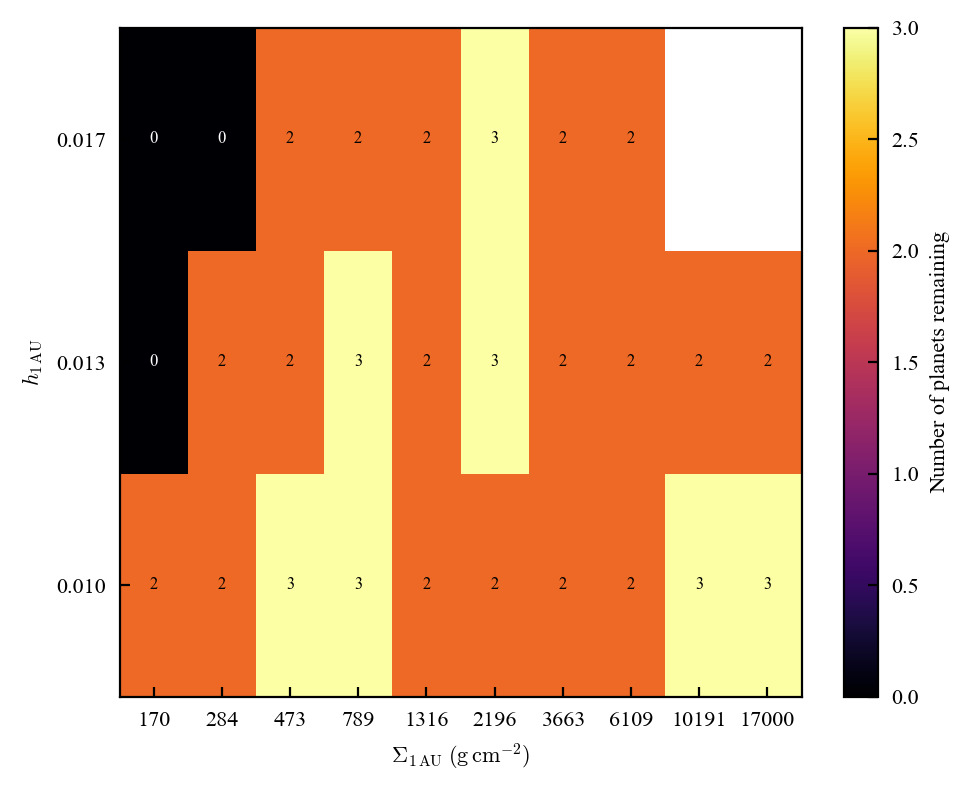

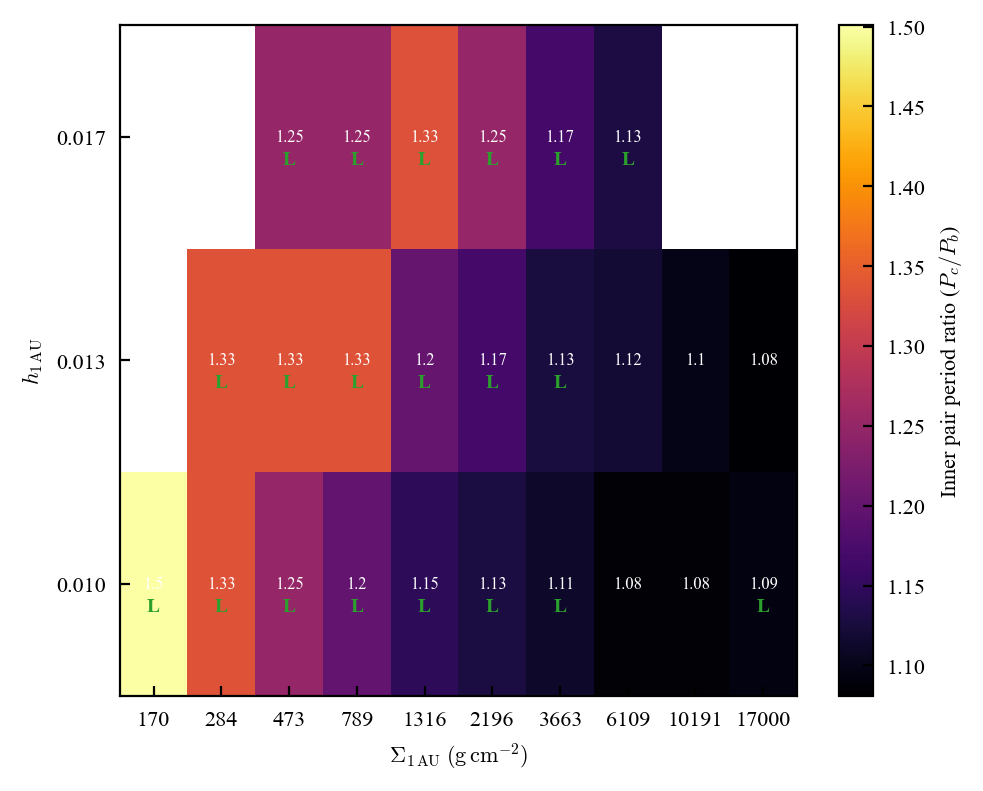

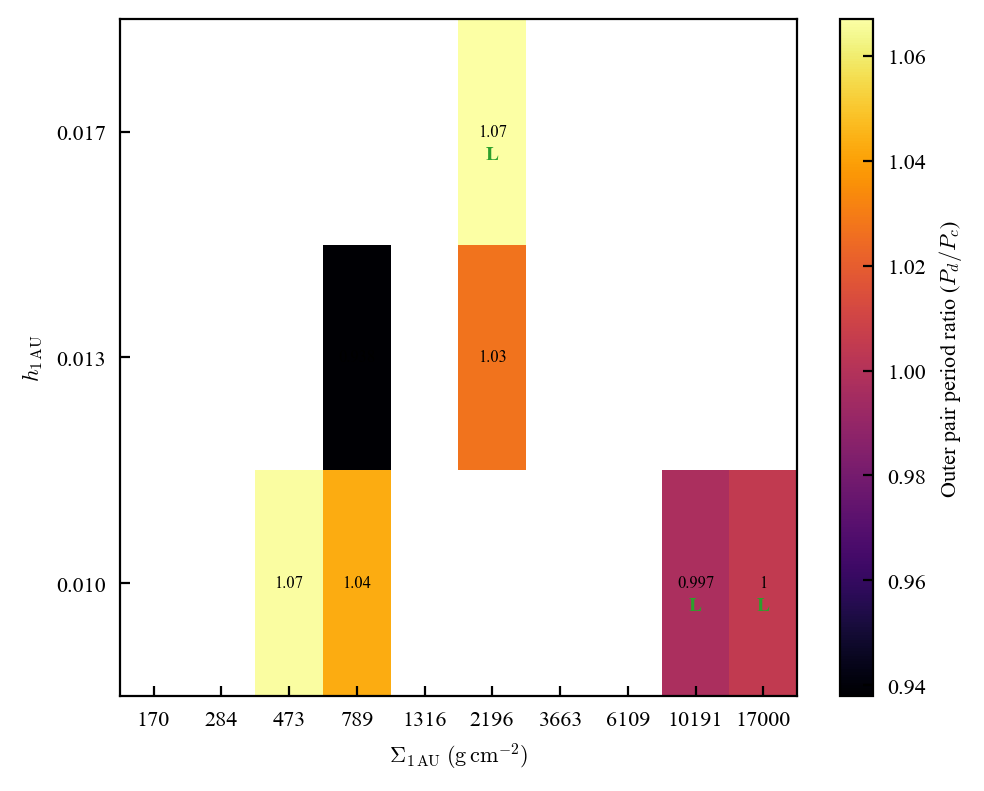

In [13]:
def plot_param_map(outcomes, value_col, label, cmap='inferno', vmin=None, vmax=None, exp=False, log_cmap=False, black_threshold=0.5):
    x_vals = np.sort(outcomes["Sigma_1au"].unique())
    y_vals = np.sort(outcomes["h_1au"].unique())
        
    # Grid
    grid = (
        outcomes
        .pivot(index="Sigma_1au",
               columns="h_1au",
               values=value_col)
        .reindex(index=x_vals,
                 columns=y_vals)
    )

    values = grid.values

    # Libration grid
    if value_col == "inner_P_ratio":
        libration_grid = (
            outcomes
            .pivot(index="Sigma_1au", columns="h_1au", values="inner_librates")
            .reindex(index=x_vals, columns=y_vals)
        )
    elif value_col == "outer_P_ratio":
        libration_grid = (
            outcomes
            .pivot(index="Sigma_1au", columns="h_1au", values="outer_librates")
            .reindex(index=x_vals, columns=y_vals)
        )
    else:
        libration_grid = None

    # Edges 
    x_edges = np.empty(len(x_vals)+1)
    x_edges[1:-1] = np.sqrt(x_vals[:-1] * x_vals[1:])
    x_edges[0] = x_vals[0]**2 / x_edges[1]
    x_edges[-1] = x_vals[-1]**2 / x_edges[-2]

    y_edges = np.empty(len(y_vals)+1)
    y_edges[1:-1] = np.sqrt(y_vals[:-1] * y_vals[1:])
    y_edges[0] = y_vals[0]**2 / y_edges[1]
    y_edges[-1] = y_vals[-1]**2 / y_edges[-2]
    
    # Plotting
    fig, ax = plt.subplots(figsize=(5,4))
    norm = LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        values.T,
        cmap=cmap,
        norm=norm,
        shading="flat"
    )

    ax.set_xlabel(r"$\Sigma_{1\,\rm AU}\;(\mathrm{g\,cm^{-2}})$")
    ax.set_ylabel(r"$h_{1\,\rm AU}$")
    
    # Present graph as log
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xticks(x_vals)
    ax.set_yticks(y_vals)

    ax.set_xticklabels([f"{x:.0f}" for x in x_vals])
    ax.set_yticklabels([f"{y:.3f}" for y in y_vals])

    ax.minorticks_off()

    # Cell text
    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):

            value = values[i, j]
            if np.isnan(value):
                continue

            color = "black"
            if value < black_threshold:
                color = "white"
    
            ax.text(
                x, y,
                f"{value:.2e}" if exp else f"{value:.3g}",
                ha="center",
                va="center",
                fontsize=6,
                color=color
            )

            if libration_grid is not None:
                if libration_grid.values[i, j]:
                    ax.annotate(
                        "L",
                        xy=(x, y),
                        xytext=(0, -5),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=7,
                        color="C2",
                        fontweight="bold"
                    )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(label)

    plt.tight_layout()
    plt.show()
    
%matplotlib inline
plot_param_map(outcomes, "pl_survived", "Number of planets remaining", cmap='inferno', vmin=1, black_threshold=1.5)
plot_param_map(outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", black_threshold=1.6)
plot_param_map(outcomes, "outer_P_ratio", r"Outer pair period ratio ($P_d/P_c$)")
# plot_param_map(outcomes, "surv_rate", "Fraction of planetesimals remaining (%)")
# plot_param_map(outcomes, "ejec_rate", "Fraction of planetesimals ejected (%)")

In [ ]:
def plot_ae_snapshot(saved_sim, *snapshot_times):
    """Plot a vs e at a one or more snapshots.
    """

    sim_data = saved_sim[0]

    # Use first body to get time array
    first_name = rock_names[0]
    times = sim_data[first_name]["time"]

    # Get idxs that best match the times given
    snapshot_idxs = np.array([
        np.argmin(np.abs(times - t))
        for t in snapshot_times
    ]) 

    num_plots = len(snapshot_times)
    fig, axs = plt.subplots(num_plots, 1, sharex=True, figsize=(4.5, 1.5 * num_plots))

    for i, ax in enumerate(axs):
        snapshot_idx = snapshot_idxs[i]
        
        # planets
        for j in range(num_pl):
            name = rock_names[j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=100,
                # label=name,
                zorder=3,
                alpha=1
            )

        # embryos
        for j in range(num_em):
            name = rock_names[num_pl + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=25,
                color='navy',
                alpha=0.75
            )

        # planetesimals
        for j in range(num_ptsml):
            name = rock_names[num_pl + num_em + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=5,
                c='k',
                alpha=0.75
            )

        if i == num_plots - 1:
            ax.set_xlabel("Semi-major axis (AU)")
        ax.set_ylabel("Eccentricity")
        ax.set_ylim(-0.01, 0.31)
        ax.set_xlim(0.1, 3)
        ax.set_xscale('log')
        ax.grid(True)
        ax.set_axisbelow(True)

        t = times[snapshot_idx]
        ax.legend(title=f"t = {t/1000:.1f} kyr", title_fontsize=8, labelspacing=0)
        
    fig.subplots_adjust(hspace=0)
    # plt.suptitle("Snapshots of Disk Evolution")
    plt.tight_layout()
    plt.show()
    # plt.savefig("disk_snapshots.svg", bbox_inches="tight")
    
end = saved_sim[0]['planet b']['time'].iloc[-1]
# plot_ae_snapshot(saved_sim, 0, end/6, end/4+100, end/2+100, 3*end/4)

In [ ]:
def plot_taus(sim_data, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    times = sim_data[0]['planet b']['time']
    planet_names = list(sim_data[0].keys())
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    fig.set_figwidth(7)
    fig.set_figheight(7)

    for i in range(num_em):
        # could also try plotting log
        name = rock_names[i+num_pl]
        
        if t_units == 'kyr':
            ax1.plot(times/1000, sim_data[0][name]["tau_a"], label=name)
            ax2.plot(times/1000, sim_data[0][name]["tau_e"], label=name)
            ax3.plot(times/1000, sim_data[0][name]["tau_i"], label=name)
            plt.xlabel("Time (kyr)")
            
    ax1.set_ylabel("tau_a")
    ax2.set_ylabel("tau_e")
    ax3.set_ylabel("tau_i")
    
    # ax1.set_ylim(0,5)
    # ax2.set_ylim(-0.1,0.45)
    # ax3.set_ylim(1,2.2)
    
    ax1.legend(); ax2.legend(); ax3.legend()
    ax1.grid(True); ax2.grid(True); ax3.grid(True)

    fig.subplots_adjust(hspace=0)

    plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    
# plot_taus(saved_sim, num_pl, num_em, num_ptsml)

In [ ]:
mmr_id.plot_libration(m_star, rocks['planet b'], rocks['planet c'])
mmr_id.plot_libration(m_star, rocks['planet c'], rocks['planet d'])